# YOLO11-S + Attention Gates on FPN Skip Connections: Wildfire Smoke & Fire Detection
**Architecture:** YOLO11-S with two soft attention gates inserted on FPN skip connections — Gate 1 before P4 Concat (L6 skip, 256ch) and Gate 2 before P3 Concat (L4 skip, 256ch)  
**Ablation entry:** Attention Gates on FPN skips — standalone test with vanilla backbone (no CBAM)  
**Motivation:** Skip connections carry raw backbone features (atmospheric haze, fog, overcast sky) directly into neck Concat; attention gates use the upsampled neck signal as spatial gating input to suppress confounder-dominated regions before fusion  
**Goal:** Early smoke/fire detection with reduced false positives from environmental confounders  
**Datasets:** D-Fire + NEMO + PyroNear (pyro-sdis) → unified corpus of ~55,698 images  
**Weight init:** Cold start — factory `yolo11s.pt` weights only; no transfer from any locally-trained checkpoint (clean control)

## 1. Setup


In [1]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
import cv2

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.1 MB/s eta 0:00:00a 0:00:01
Torch       : 2.10.0+cu128
CUDA        : True
Device      : Tesla T4
Libraries loaded ✅


## 2. D-Fire — Load, Filter & Verify

**Source:** `github.com/gaia-solutions-on-demand/DFireDataset` (Kaggle: `sayedgamal99/smoke-fire-detection-yolo`)  
**Size:** 21,527 RGB images, 26,557 bounding boxes — filtered to ~18,700 by rejecting close-up shots  
**Classes:** 0=smoke, 1=fire (author convention)  
**Hard negatives:** ~9,838 images of lamp glare, sun glare, environmental confusion


In [2]:
DFIRE_PATH  = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
CLASS_NAMES = ["smoke", "fire"]
COLORS      = [(0.39, 0.71, 1.0), (1.0, 0.31, 0.0)]

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        lbls = list(lbl_dir.glob("*.txt"))
        print(f"D-Fire {split:5s}: {len(imgs):6d} images | {len(lbls):6d} labels")
    else:
        print(f"D-Fire {split}: path not found")


D-Fire train:  14122 images |  14122 labels
D-Fire val  :   3099 images |   3099 labels
D-Fire test :   4306 images |   4306 labels


In [3]:
def is_distant_shot(label_path, max_box_area=0.40):
    """
    Returns True if image is a distant/tower-camera shot.
    Rejects images where any bounding box covers >40% of the frame.
    Close-up shots (kitchen fires, indoor) have large boxes;
    distant wildfire tower shots have small boxes.
    """
    lbl = Path(label_path)
    if not lbl.exists():
        return True  # no label = negative sample, keep
    with open(lbl) as f:
        lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines):
        return True  # empty label = negative, keep
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area:
            return False
    return True


print("Filtering D-Fire (max box area = 40%)...")
dfire_kept     = {}
dfire_rejected = {}

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept, rejected = [], []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if is_distant_shot(lbl_path):
            kept.append(img_path)
        else:
            rejected.append(img_path)
    dfire_kept[split]     = kept
    dfire_rejected[split] = rejected
    pct = len(rejected) / max(len(kept) + len(rejected), 1) * 100
    print(f"  {split:5s}: kept {len(kept):6d} | rejected {len(rejected):5d} ({pct:.1f}% removed)")

total_kept     = sum(len(v) for v in dfire_kept.values())
total_rejected = sum(len(v) for v in dfire_rejected.values())
print(f"\nTotal kept: {total_kept} | rejected: {total_rejected} "
      f"({total_rejected/(total_kept+total_rejected)*100:.1f}% overall)")


Filtering D-Fire (max box area = 40%)...
  train: kept  12270 | rejected  1852 (13.1% removed)
  val  : kept   2676 | rejected   423 (13.6% removed)
  test : kept   3754 | rejected   552 (12.8% removed)

Total kept: 18700 | rejected: 2827 (13.1% overall)


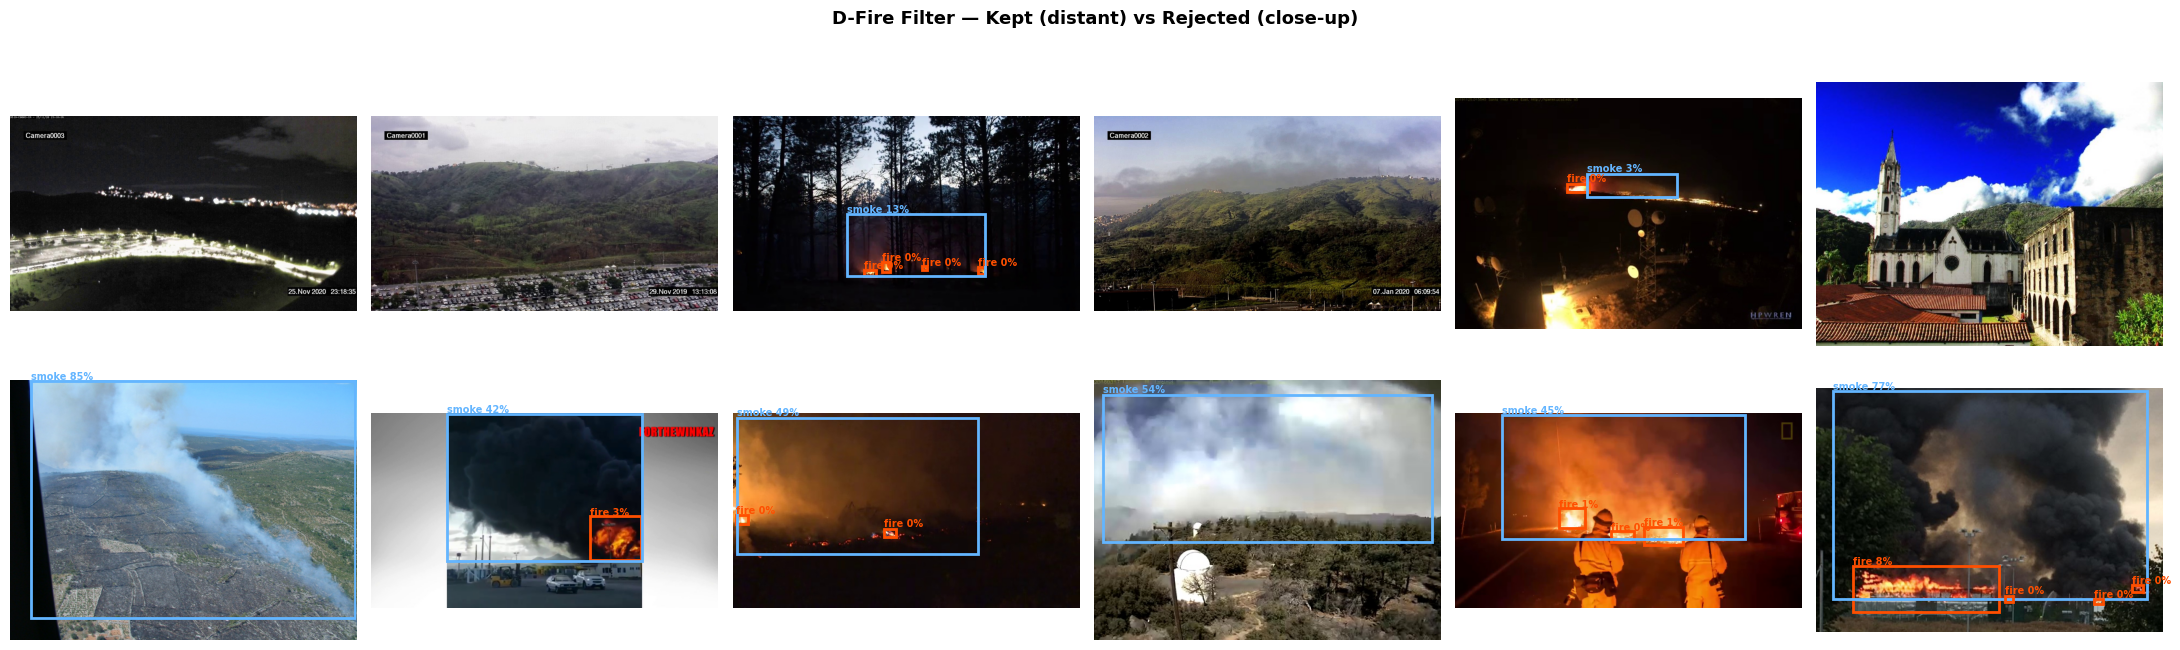

In [4]:
# Visual check: kept (distant) vs rejected (close-up)
def draw_boxes(ax, img_path, lbl_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    if Path(lbl_path).exists():
        for line in open(lbl_path).readlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
            x1, y1 = (xc - bw/2)*W, (yc - bh/2)*H
            c = COLORS[cls % len(COLORS)]
            ax.add_patch(patches.Rectangle((x1, y1), bw*W, bh*H,
                         linewidth=2, edgecolor=c, facecolor='none'))
            ax.text(x1, y1-4, f"{CLASS_NAMES[cls]} {bw*bh*100:.0f}%",
                    color=c, fontsize=7, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
fig.suptitle("D-Fire Filter — Kept (distant) vs Rejected (close-up)",
             fontsize=13, fontweight='bold')

for i, img_path in enumerate(random.sample(dfire_kept["train"], min(6, len(dfire_kept["train"])))):
    lbl = Path(DFIRE_PATH) / "train" / "labels" / f"{img_path.stem}.txt"
    draw_boxes(axes[0][i], img_path, lbl)
    if i == 0: axes[0][i].set_ylabel("KEPT", fontsize=10, fontweight='bold', color='green')

for i, img_path in enumerate(random.sample(dfire_rejected["train"], min(6, len(dfire_rejected["train"])))):
    lbl = Path(DFIRE_PATH) / "train" / "labels" / f"{img_path.stem}.txt"
    draw_boxes(axes[1][i], img_path, lbl)
    if i == 0: axes[1][i].set_ylabel("REJECTED", fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()


## 3. NEMO — Convert COCO JSON → YOLO

**Source:** `github.com/SayBender/Nemo` (Kaggle: `werus23/nevada-smoke-detection-data`)  
**Size:** 2,934 images, 4,522 labeled smoke bounding boxes  
**Classes:** Smoke only (low/mid/high density → collapsed to class 0)


In [5]:
NEMO_BASE       = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
NEMO_TRAIN_IMGS = f"{NEMO_BASE}/NEMO data/train_images"
NEMO_VAL_IMGS   = f"{NEMO_BASE}/NEMO data/val_images"
NEMO_TRAIN_JSON = f"{NEMO_BASE}/NEMO data/annotation_train.json"
NEMO_VAL_JSON   = f"{NEMO_BASE}/NEMO data/annotation_val.json"
NEMO_2023_IMGS  = f"{NEMO_BASE}/20-23_daytime_images/daytime images"
NEMO_2023_JSON  = f"{NEMO_BASE}/20-23_daytime_label.json"


def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir, smoke_class=0):
    """Convert COCO JSON annotations → YOLO format. All smoke classes → class 0."""
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    with open(json_path) as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)
    converted = copied = 0
    for img_id, img_info in img_map.items():
        W, H   = img_info["width"], img_info["height"]
        fname  = Path(img_info["file_name"]).stem
        src    = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists():
            shutil.copy2(src, Path(img_dst_dir) / src.name)
            copied += 1
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            xc, yc = (x + w/2)/W, (y + h/2)/H
            wn, hn = w/W, h/H
            lines.append(f"{smoke_class} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  Converted {converted} labels, copied {copied} images")


print("Converting NEMO train...")
coco_to_yolo(NEMO_TRAIN_JSON, NEMO_TRAIN_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("Converting NEMO val...")
coco_to_yolo(NEMO_VAL_JSON, NEMO_VAL_IMGS,
             "/kaggle/working/nemo_yolo/images/val",
             "/kaggle/working/nemo_yolo/labels/val")

print("Merging 20-23 daytime into train...")
coco_to_yolo(NEMO_2023_JSON, NEMO_2023_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("\nNEMO conversion complete:")
for split in ["train", "val"]:
    imgs = list(Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"))
    print(f"  {split}: {len(imgs)} images | {len(lbls)} labels")


Converting NEMO train...
  Converted 2680 labels, copied 2680 images
Converting NEMO val...
  Converted 250 labels, copied 250 images
Merging 20-23 daytime into train...
  Converted 432 labels, copied 432 images

NEMO conversion complete:
  train: 3112 images | 3112 labels
  val: 250 images | 250 labels


## 4. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

**Source:** `pyronear/pyro-sdis` on HuggingFace (public, no token required)  
**Size:** 33,636 images | Smoke only (class 0) | ~16% hard negatives (empty label files)  
**Camera setup:** Fixed outdoor cameras from SDIS French fire brigade


In [6]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

for split_name, split in [("Train", ds["train"]), ("Val", ds["val"])]:
    has_smoke = sum(1 for s in split if s["annotations"] and s["annotations"].strip())
    no_smoke  = len(split) - has_smoke
    print(f"\n{split_name}:")
    print(f"  Smoke positives  : {has_smoke}")
    print(f"  Hard negatives   : {no_smoke} ({no_smoke/len(split):.1%})")


Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099

Train:
  Smoke positives  : 24792
  Hard negatives   : 4745 (16.1%)

Val:
  Smoke positives  : 3345
  Hard negatives   : 754 (18.4%)


In [7]:
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)


def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")


print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")


Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


## 5. Merge → Unified YOLO Dataset


In [8]:
UNIFIED = "/kaggle/working/unified_dataset"

for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

# ── D-Fire (filtered) ─────────────────────────────────────────────────
print("Copying D-Fire (filtered)...")
for split in ["train", "val", "test"]:
    for img_path in dfire_kept[split]:
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists():
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")
print("  D-Fire ✅")

# ── NEMO ──────────────────────────────────────────────────────────────
print("Copying NEMO...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/nemo_{img.name}")
    for lbl in Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/nemo_{lbl.name}")
print("  NEMO ✅")

# ── PyroNear ──────────────────────────────────────────────────────────
print("Copying PyroNear...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/pyro_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/pyro_{img.name}")
    for lbl in Path(f"/kaggle/working/pyro_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/pyro_{lbl.name}")
print("  PyroNear ✅")

# ── Summary ───────────────────────────────────────────────────────────
print("\n── Unified Dataset ──────────────────────────────")
total = 0
for split in ["train", "val", "test"]:
    imgs = list(Path(f"{UNIFIED}/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"{UNIFIED}/labels/{split}").glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | "
          f"{pos:6d} positive | {neg:5d} negative ({neg/max(len(lbls),1):.1%})")
    total += len(imgs)
print(f"  TOTAL: {total} images")

print("\n── Source Breakdown ────────────────────────────")
for split in ["train", "val"]:
    dfire = len(list(Path(f"{UNIFIED}/images/{split}").glob("dfire_*")))
    nemo  = len(list(Path(f"{UNIFIED}/images/{split}").glob("nemo_*")))
    pyro  = len(list(Path(f"{UNIFIED}/images/{split}").glob("pyro_*")))
    print(f"  {split}: D-Fire={dfire} | NEMO={nemo} | PyroNear={pyro}")


Copying D-Fire (filtered)...
  D-Fire ✅
Copying NEMO...
  NEMO ✅
Copying PyroNear...
  PyroNear ✅

── Unified Dataset ──────────────────────────────
  train:  44919 images |  33716 positive | 11203 negative (24.9%)
  val  :   7025 images |   4896 positive |  2129 negative (30.3%)
  test :   3754 images |   1749 positive |  2005 negative (53.4%)
  TOTAL: 55698 images

── Source Breakdown ────────────────────────────
  train: D-Fire=12270 | NEMO=3112 | PyroNear=29537
  val: D-Fire=2676 | NEMO=250 | PyroNear=4099


## 6. Data YAML + Integrity Check


In [9]:
yaml_content = """# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)


# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire



In [10]:
print("── Dataset Integrity Check ────────────────────────────────────")
for split in ["train", "val", "test"]:
    img_dir = Path(f"{UNIFIED}/images/{split}")
    lbl_dir = Path(f"{UNIFIED}/labels/{split}")
    imgs = {p.stem for p in img_dir.glob("*.jpg")}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}
    print(f"\n  {split.upper()}")
    print(f"    Images         : {len(imgs)}")
    print(f"    Labels         : {len(lbls)}")
    print(f"    Matched pairs  : {len(imgs & lbls)}")
    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    if imgs_no_lbl: print(f"    ⚠️  Images w/o label: {len(imgs_no_lbl)}")
    if lbls_no_img: print(f"    ⚠️  Labels w/o image: {len(lbls_no_img)}")
    for prefix in ["dfire", "nemo", "pyro"]:
        n_i = len(list(img_dir.glob(f"{prefix}_*.jpg")))
        n_l = len(list(lbl_dir.glob(f"{prefix}_*.txt")))
        mark = "✅" if n_i == n_l else "⚠️"
        print(f"    {mark} {prefix:8s}: {n_i} imgs | {n_l} lbls")


── Dataset Integrity Check ────────────────────────────────────

  TRAIN
    Images         : 44919
    Labels         : 44919
    Matched pairs  : 44919
    ✅ dfire   : 12270 imgs | 12270 lbls
    ✅ nemo    : 3112 imgs | 3112 lbls
    ✅ pyro    : 29537 imgs | 29537 lbls

  VAL
    Images         : 7025
    Labels         : 7025
    Matched pairs  : 7025
    ✅ dfire   : 2676 imgs | 2676 lbls
    ✅ nemo    : 250 imgs | 250 lbls
    ✅ pyro    : 4099 imgs | 4099 lbls

  TEST
    Images         : 3754
    Labels         : 3754
    Matched pairs  : 3754
    ✅ dfire   : 3754 imgs | 3754 lbls
    ✅ nemo    : 0 imgs | 0 lbls
    ✅ pyro    : 0 imgs | 0 lbls


## 7. AttentionGate Module Definition

**Reference:** Oktay et al., MICCAI 2018 — https://arxiv.org/abs/1807.06521  
**Insertion points (vanilla backbone, no CBAM):**  
- Gate 1 — L12, before P4 Concat: gates L6 skip (256ch) using upsampled C2PSA gating signal (512ch) → 256ch  
- Gate 2 — L16, before P3 Concat: gates L4 skip (256ch) using upsampled L14 gating signal (256ch) → 256ch  

**Mechanism:** W_x (1×1 conv, skip) + W_g (1×1 conv, gating signal) → BN → ReLU → psi (1×1 conv → sigmoid) → spatial mask → x × mask  
**Forward signature:** `forward(inputs)` receives `[x, g]` (list of two tensors) — required by Ultralytics multi-from layer dispatch  
**Total parameter overhead:** ~12K across both gates (negligible vs 9.4M baseline)

In [ ]:
import torch.nn.functional as F

class AttentionGate(nn.Module):
    """
    Soft attention gate — Oktay et al., MICCAI 2018.
    Gates skip feature x using a coarser gating signal g.

    forward() receives a list [x, g] — Ultralytics multi-from dispatch.
    If g and x have different spatial sizes, g is interpolated to match x.

    Args:
        x_ch    : channels of skip feature (actual, post gw-scale)
        g_ch    : channels of gating signal (actual, post gw-scale)
        inter_ch: bottleneck dim for W_x / W_g (default: x_ch // 2)
    """
    def __init__(self, x_ch, g_ch, inter_ch=None):
        super().__init__()
        inter_ch = inter_ch or max(x_ch // 2, 1)
        self.W_x     = nn.Conv2d(x_ch,     inter_ch, kernel_size=1, bias=False)
        self.W_g     = nn.Conv2d(g_ch,     inter_ch, kernel_size=1, bias=False)
        self.psi     = nn.Conv2d(inter_ch, 1,        kernel_size=1, bias=False)
        self.bn      = nn.BatchNorm2d(inter_ch)
        self.relu    = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, inputs):
        x, g = inputs                           # x: skip feat, g: gating signal
        x1   = self.W_x(x)
        g1   = self.W_g(g)
        if g1.shape[2:] != x1.shape[2:]:       # spatial alignment guard
            g1 = F.interpolate(g1, size=x1.shape[2:], mode='nearest')
        attn = self.sigmoid(self.psi(self.relu(self.bn(x1 + g1))))
        return x * attn                         # gated skip, same shape as x


# ── Sanity check ──────────────────────────────────────────────────────────────
gate_configs = [
    ("Gate1 P4", 256, 512),   # skip=L6(256ch), gating=C2PSA upsample(512ch)
    ("Gate2 P3", 256, 256),   # skip=L4(256ch), gating=L14 upsample(256ch)
]
for label, x_ch, g_ch in gate_configs:
    _x   = torch.randn(2, x_ch, 40, 40)
    _g   = torch.randn(2, g_ch, 40, 40)
    _ag  = AttentionGate(x_ch=x_ch, g_ch=g_ch)
    _out = _ag([_x, _g])
    assert _out.shape == _x.shape, f"Shape mismatch: {_out.shape} != {_x.shape}"
    params = sum(p.numel() for p in _ag.parameters())
    inter  = max(x_ch // 2, 1)
    print(f"{label}  x:{x_ch}ch  g:{g_ch}ch  inter:{inter}ch | "
          f"input {tuple(_x.shape)} → output {tuple(_out.shape)} | params {params:,} ✅")

## 8. Register AttentionGate into Ultralytics Runtime

In [ ]:
import ultralytics.nn.modules as ulm
import ultralytics.nn.modules.conv as conv_mod
import ultralytics.nn.tasks as tasks_mod

# 1. Inject into module namespaces so sub-imports resolve
for mod in [conv_mod, ulm, tasks_mod]:
    mod.AttentionGate = AttentionGate

# 2. Upfront globals fallback — required for this Ultralytics version;
#    module_map dict scan does not reliably find custom modules (e.g. C2PSA).
tasks_mod.__dict__['AttentionGate'] = AttentionGate

print("AttentionGate registered into Ultralytics runtime ✅")
print(f"  conv_mod.AttentionGate : {conv_mod.AttentionGate}")
print(f"  ulm.AttentionGate      : {ulm.AttentionGate}")
print(f"  tasks_mod.__dict__     : AttentionGate → {tasks_mod.__dict__['AttentionGate']}")

## 9. Attention Gate YAML — Modified YOLO11-S Architecture

**Config: vanilla backbone + two attention gates on FPN skip connections**

| Position  | Layer | Gate inputs                     | YAML args   | Output ch | Notes                          |
|-----------|-------|---------------------------------|-------------|-----------|--------------------------------|
| Gate 1    | L12   | x=L6 skip (256ch), g=L11 (512ch)| `[256, 512]`| 256ch     | P4 skip gating, before Concat  |
| Gate 2    | L16   | x=L4 skip (256ch), g=L15 (256ch)| `[256, 256]`| 256ch     | P3 skip gating, before Concat  |

Backbone is vanilla (no CBAM) — clean isolation of the attention gate contribution.  
Each gate adds one layer (+1 index shift each); all head indices shift vs vanilla by +0 through +2.  
Detect reads **[18, 21, 24]** (P3 C3k2 | P4 C3k2 | P5 C3k2).

In [ ]:
ag_yaml_str = """
# YOLO11-S + Attention Gates on FPN Skip Connections
# Gate mechanism: Oktay et al., MICCAI 2018 (https://arxiv.org/abs/1807.06521)
#
# Motivation: Skip connections at L12-Concat (P4, from L6) and L17-Concat (P3, from L4)
# feed raw backbone features — atmospheric haze, fog — into neck fusion.
# Attention gates intercept each skip before Concat, using the upsampled neck
# signal as a spatial gating input to suppress confounder-dominated regions.
#
# Insertion points (gw=0.50 applied, all ch counts are actual post-scale):
#   Gate 1 (L12) — gates L6 skip (256ch) using upsampled C2PSA gating (512ch) → 256ch
#   Gate 2 (L16) — gates L4 skip (256ch) using upsampled L14 gating (256ch)   → 256ch
#
# Backbone: vanilla (no CBAM) — clean isolation of AG contribution
# Head index shifts vs vanilla YOLO11-S:
#   L11       : +0   (Upsample, unchanged)
#   L12       : NEW  (AttentionGate Gate1 replaces vanilla Concat)
#   L13-L14   : +1   (Concat + C3k2)
#   L15       : +1   (Upsample)
#   L16       : NEW  (AttentionGate Gate2)
#   L17-L18   : +2   (Concat + C3k2 P3 output)
#   L19-L24   : +2   (Conv, Concat, C3k2 ×3 P4/P5)
# Detect reads [18, 21, 24]  (P3 C3k2 | P4 C3k2 | P5 C3k2)

nc: 2  # smoke=0, fire=1

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]           # 0   P1/2
  - [-1, 1, Conv,  [128, 3, 2]]          # 1   P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]   # 2
  - [-1, 1, Conv,  [256, 3, 2]]          # 3   P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]   # 4   P3 skip (256ch actual)
  - [-1, 1, Conv,  [512, 3, 2]]          # 5   P4/16
  - [-1, 2, C3k2,  [512, True]]          # 6   P4 skip (256ch actual)
  - [-1, 1, Conv,  [1024, 3, 2]]         # 7   P5/32
  - [-1, 2, C3k2,  [1024, True]]         # 8
  - [-1, 1, SPPF,  [1024, 5]]            # 9
  - [-1, 2, C2PSA, [1024]]               # 10  512ch actual (vanilla position, no CBAM)

head:
  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 11  upsample C2PSA (512ch)
  - [[6, 11],  1, AttentionGate, [256, 512]]           # 12  Gate1: gate L6(256ch) via L11(512ch) → 256ch
  - [[-1, 11], 1, Concat,        [1]]                  # 13  gated_skip(256) + upsample(512) = 768ch
  - [-1,       2, C3k2,          [512, False]]         # 14  768ch → 256ch actual

  - [-1,       1, nn.Upsample,   [None, 2, nearest]]  # 15  upsample L14 (256ch)
  - [[4, 15],  1, AttentionGate, [256, 256]]           # 16  Gate2: gate L4(256ch) via L15(256ch) → 256ch
  - [[-1, 15], 1, Concat,        [1]]                  # 17  gated_skip(256) + upsample(256) = 512ch
  - [-1,       2, C3k2,          [256, False]]         # 18  P3 output → 128ch actual

  - [-1,       1, Conv,          [256, 3, 2]]          # 19  stride-2
  - [[-1, 14], 1, Concat,        [1]]                  # 20  cat P4 neck (L14, 256ch)
  - [-1,       2, C3k2,          [512, False]]         # 21  P4 → 256ch actual

  - [-1,       1, Conv,          [512, 3, 2]]          # 22  stride-2
  - [[-1, 10], 1, Concat,        [1]]                  # 23  cat C2PSA (L10, 512ch)
  - [-1,       2, C3k2,          [1024, True]]         # 24  P5 → 512ch actual

  - [[18, 21, 24], 1, Detect, [nc]]                    # 25
"""

with open("/kaggle/working/yolo11s_ag_skip.yaml", "w") as f:
    f.write(ag_yaml_str.strip())
print("yolo11s_ag_skip.yaml written ✅")

# ── Architecture sanity check — must find exactly 2 AttentionGate layers ──────
from ultralytics import YOLO
test_model = YOLO("/kaggle/working/yolo11s_ag_skip.yaml")
ag_count = 0
print("\nLayer index | Type")
print("-" * 40)
gate_labels = ["Gate1 (P4 skip)", "Gate2 (P3 skip)"]
for i, layer in enumerate(test_model.model.model):
    is_ag  = type(layer).__name__ == "AttentionGate"
    marker = f" ← {gate_labels[ag_count]}" if is_ag else ""
    if is_ag: ag_count += 1
    print(f"  [{i:2d}]  {type(layer).__name__}{marker}")
assert ag_count == 2, f"Expected 2 AttentionGate modules, found {ag_count}"
print(f"\n✅ {ag_count} AttentionGate modules confirmed at [L12 Gate1, L16 Gate2]")
del test_model

## 9b. Architecture Verification — Positions, Channels & Forward Pass

Checks run **before training** to catch any YAML/registration errors:
1. Layer index and module type at each expected AttentionGate position
2. Input channel counts fed into each gate: W_x.in_channels (skip) and W_g.in_channels (gating)
3. Detect layer reads exactly `[18, 21, 24]`
4. Live dummy forward pass — confirms no shape errors end-to-end

In [ ]:
import torch
from ultralytics import YOLO

print("=" * 62)
print("ARCHITECTURE VERIFICATION — YOLO11-S + Attention Gates on FPN Skips")
print("=" * 62)

verify_model = YOLO("/kaggle/working/yolo11s_ag_skip.yaml")
layers = list(verify_model.model.model)

# ── 1. AttentionGate position & type check ────────────────────────────────────
EXPECTED_GATES = {
    12: {"x_ch": 256, "g_ch": 512, "label": "Gate1 P4 skip"},
    16: {"x_ch": 256, "g_ch": 256, "label": "Gate2 P3 skip"},
}

print("\n[1] AttentionGate position & type")
print(f"    {'Layer':>6}  {'Expected':>16}  {'Found':>16}  {'Status'}")
print(f"    {'-'*56}")
pos_ok = True
for idx, cfg in EXPECTED_GATES.items():
    layer      = layers[idx]
    found_type = type(layer).__name__
    is_ag      = found_type == "AttentionGate"
    status     = "✅" if is_ag else "❌ WRONG TYPE"
    print(f"    L{idx:>2d}  ({cfg['label']:<14})  {'AttentionGate':>16}  {found_type:>16}  {status}")
    if not is_ag:
        pos_ok = False
assert pos_ok, "One or more layers at expected AttentionGate positions are not AttentionGate modules"

# ── 2. Channel size check (W_x and W_g) ──────────────────────────────────────
print("\n[2] AttentionGate channel sizes")
print(f"    {'Layer':>6}  {'x_ch (skip)':>14}  {'W_x.in':>8}  {'g_ch (gate)':>13}  {'W_g.in':>8}  {'Status'}")
print(f"    {'-'*70}")
ch_ok = True
for idx, cfg in EXPECTED_GATES.items():
    layer    = layers[idx]
    wx_in    = layer.W_x.in_channels
    wg_in    = layer.W_g.in_channels
    wx_match = wx_in == cfg["x_ch"]
    wg_match = wg_in == cfg["g_ch"]
    ok       = wx_match and wg_match
    status   = "✅" if ok else f"❌ expected x={cfg['x_ch']} g={cfg['g_ch']}"
    print(f"    L{idx:>2d}    {cfg['x_ch']:>14}  {wx_in:>8}  {cfg['g_ch']:>13}  {wg_in:>8}  {status}")
    if not ok:
        ch_ok = False
assert ch_ok, "AttentionGate channel sizes do not match expected values"

# ── 3. Detect layer inputs check ──────────────────────────────────────────────
print("\n[3] Detect layer index and input sources")
detect_layer = layers[-1]
detect_type  = type(detect_layer).__name__
print(f"    Last layer type : {detect_type}")
assert detect_type == "Detect", f"Last layer is {detect_type}, expected Detect"

model_yaml    = verify_model.model.yaml
head_entries  = model_yaml.get("head", [])
detect_entry  = head_entries[-1]
detect_from   = detect_entry[0]
expected_from = [18, 21, 24]
match  = detect_from == expected_from
status = "✅" if match else f"❌ expected {expected_from}"
print(f"    Detect from     : {detect_from}  {status}")
assert match, f"Detect reads from {detect_from}, expected {expected_from}"

# ── 4. Live forward pass ──────────────────────────────────────────────────────
print("\n[4] Live forward pass  (batch=2, 640×640)")
verify_model.model.eval()
dummy = torch.zeros(2, 3, 640, 640)
with torch.no_grad():
    out = verify_model.model(dummy)

preds = out[0] if isinstance(out, (list, tuple)) else out
nc    = verify_model.model.yaml['nc']
print(f"    Output shape    : {tuple(preds.shape)}")
print(f"    Expected        : (2, {4 + nc}, <anchors>)  → nc={nc} ✅")
assert preds.shape[0] == 2,      "Batch dim mismatch"
assert preds.shape[1] == 4 + nc, "Output channel mismatch"

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print("=" * 62)
print("ALL CHECKS PASSED ✅")
print(f"  2 AttentionGate modules confirmed at L12 (Gate1 P4) and L16 (Gate2 P3)")
print(f"  Gate1: W_x=256ch, W_g=512ch | Gate2: W_x=256ch, W_g=256ch")
print(f"  Detect reads [18, 21, 24]")
print(f"  Forward pass clean — output {tuple(preds.shape)}")
print("=" * 62)

del verify_model
torch.cuda.empty_cache()

## 10. Cold Start — Transfer Factory yolo11s.pt Weights

**Control study constraints:**
- Source: factory `yolo11s.pt` (ImageNet pretrained, nc=80) — no locally-trained weights
- Transferred: full backbone L0–L10 (vanilla, including C2PSA) + all transferable neck layers
- Random init: AttentionGate Gate1 [L12] | AttentionGate Gate2 [L16] | Detect head [L25]

**Index remapping** (vanilla YOLO11-S → new AG architecture):

| vanilla layer | type              | new index | shift | reason                                   |
|---------------|-------------------|-----------|-------|------------------------------------------|
| L0–L10        | backbone          | L0–L10    | +0    | vanilla backbone unchanged               |
| L11           | Upsample          | L11       | +0    | no shift yet (no params)                 |
| L12           | Concat            | —         | —     | new L12 is AttentionGate — skip          |
| L13           | C3k2              | L14       | +1    | +1 for Gate1 at new L12                  |
| L14           | Upsample          | L15       | +1    | +1 (no params)                           |
| L15           | Concat            | —         | —     | new L16 is AttentionGate — skip          |
| L16           | C3k2 (P3)         | L18       | +2    | +2 for Gate1 + Gate2                     |
| L17           | Conv              | L19       | +2    |                                          |
| L18           | Concat            | —         | —     | no params, skip                          |
| L19           | C3k2 (P4)         | L21       | +2    |                                          |
| L20           | Conv              | L22       | +2    |                                          |
| L21           | Concat            | —         | —     | no params, skip                          |
| L22           | C3k2 (P5)         | L24       | +2    |                                          |
| L23           | Detect            | —         | —     | nc=80→2 mismatch, skip                   |

In [ ]:
from ultralytics import YOLO
import torch

print("Building YOLO11-S + Attention Gates and cold-starting from factory yolo11s.pt...")
print("(No transfer from any locally-trained checkpoint — clean control study)\n")

# 1. Fresh skeleton from AG YAML
ag_model = YOLO("/kaggle/working/yolo11s_ag_skip.yaml")

# 2. Factory pretrained donor (vanilla YOLO11-S, nc=80)
base_model      = YOLO("yolo11s.pt")
base_state_dict = base_model.model.state_dict()

# 3. Target state dict
ag_state_dict = ag_model.model.state_dict()

# 4. Layer index remapping — vanilla YOLO11-S → new AG architecture
#    Concat layers (L12, L15, L18, L21 vanilla) have no learnable params
#    and are skipped naturally by the shape-mismatch guard below.
#    Explicit None return signals: skip this key entirely (Detect nc mismatch).
IDX_REMAP = {
    **{i: i for i in range(11)},  # backbone L0–L10: unchanged
    11: 11,   # Upsample → Upsample  (no params, but included for completeness)
    # 12 vanilla Concat → no params, skipped naturally
    13: 14,   # C3k2 (P4 neck)  +1 for Gate1 at new L12
    14: 15,   # Upsample        +1
    # 15 vanilla Concat → no params
    16: 18,   # C3k2 (P3)       +2 for Gate1 + Gate2
    17: 19,   # Conv stride-2   +2
    # 18 vanilla Concat → no params
    19: 21,   # C3k2 (P4)       +2
    20: 22,   # Conv stride-2   +2
    # 21 vanilla Concat → no params
    22: 24,   # C3k2 (P5)       +2
    # 23 vanilla Detect → nc=80 mismatch, explicit None → skip
}

def remap_idx(base_idx):
    return IDX_REMAP.get(base_idx, None)   # None → skip

transferred     = 0
skipped_shape   = 0
skipped_missing = 0

for k, v in base_state_dict.items():
    parts = k.split('.')
    if len(parts) > 1 and parts[1].isdigit():
        new_layer_idx = remap_idx(int(parts[1]))
        if new_layer_idx is None:
            skipped_missing += 1
            continue
        parts[1] = str(new_layer_idx)
        new_key  = '.'.join(parts)
    else:
        new_key = k

    if new_key not in ag_state_dict:
        skipped_missing += 1
        continue
    if ag_state_dict[new_key].shape != v.shape:
        skipped_shape += 1
        continue

    ag_state_dict[new_key] = v
    transferred += 1

ag_model.model.load_state_dict(ag_state_dict, strict=False)

print(f"Transferred           : {transferred} weight tensors")
print(f"Skipped (shape)       : {skipped_shape}  ← Detect nc=80→2 mismatch, expected")
print(f"Skipped (key missing) : {skipped_missing}  ← 2 AttentionGate modules → random init")
print()
print("Warm-started : backbone L0–L10 (full, including C2PSA) + neck L11, L14–L15, L18–L19, L21–L22, L24")
print("Random init  : AttentionGate Gate1 [L12] | AttentionGate Gate2 [L16]")
print("Random init  : Detect head [L25]  (nc=2, new task head)")

ag_model.save("/kaggle/working/yolo11s_ag_skip_init.pt")
print("\nSaved → /kaggle/working/yolo11s_ag_skip_init.pt ✅")
del base_model

In [ ]:
ag_l12 = ag_model.model.model[12]
ag_l16 = ag_model.model.model[16]

print("AttentionGate weight init check (should be non-zero random, not warm-started):")
for name, ag in [("L12 Gate1 (P4)", ag_l12), ("L16 Gate2 (P3)", ag_l16)]:
    wx = ag.W_x.weight
    wg = ag.W_g.weight
    print(f"  {name}")
    print(f"    W_x — mean: {wx.mean():.6f}  std: {wx.std():.6f}  all_zeros: {(wx == 0).all().item()}")
    print(f"    W_g — mean: {wg.mean():.6f}  std: {wg.std():.6f}  all_zeros: {(wg == 0).all().item()}")

## 11. Train YOLO11-S + Attention Gates on FPN Skip Connections

In [ ]:
ag_model = YOLO("/kaggle/working/yolo11s_ag_skip_init.pt")

results_ag = ag_model.train(
    data     = "/kaggle/working/data.yaml",
    epochs   = 30,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    project  = "/kaggle/working/runs",
    name     = "yolo11s_ag_skip",
    patience = 10,
    save     = True,
    plots    = True,
    val      = True,
    workers  = 2,
    exist_ok = True,
)

shutil.make_archive("/kaggle/working/yolo11s_ag_skip_results", "zip",
                    "/kaggle/working/runs/yolo11s_ag_skip")
print("Attention Gates training complete — results zipped ✅")

## 12. Training Curves

In [ ]:
AG_DIR  = "/kaggle/working/runs/yolo11s_ag_skip"
BEST_PT = f"{AG_DIR}/weights/best.pt"

df = pd.read_csv(f"{AG_DIR}/results.csv")
df.columns = df.columns.str.strip()

print("── Per-epoch summary ──────────────────────────────────────────")
print(df[["epoch",
          "train/box_loss", "val/box_loss",
          "metrics/mAP50(B)",
          "metrics/precision(B)",
          "metrics/recall(B)"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO11-S + Attention Gates on FPN Skip Connections — Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/ag_skip_training_curves.png", dpi=120)
plt.show()

## 13. Evaluation

Three evaluation passes:
- **Eval A** — D-Fire test set (3,754 images) — cross-dataset generalization
- **Eval B** — Combined val set (7,025 images) — all three source distributions
- **Eval C** — PyroNear val only — in-distribution tower camera performance

In [ ]:
# Full memory reset before evaluation
try:
    del ag_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

eval_model = YOLO(BEST_PT)
lbl_test   = Path(f"{UNIFIED}/labels/test")
img_test   = Path(f"{UNIFIED}/images/test")
lbl_val    = Path(f"{UNIFIED}/labels/val")
img_val    = Path(f"{UNIFIED}/images/val")


def batched_fp_rate(model, hard_neg_imgs, batch_size=200):
    """Compute FP rate on hard negative images in batches to avoid OOM."""
    fp = 0
    for i in range(0, len(hard_neg_imgs), batch_size):
        preds = model.predict(source=hard_neg_imgs[i:i+batch_size],
                              imgsz=640, conf=0.25, device=0, verbose=False)
        fp += sum(1 for r in preds if len(r.boxes) > 0)
        torch.cuda.empty_cache()
    return fp, fp / len(hard_neg_imgs) if hard_neg_imgs else 0


def get_hard_negs(img_dir, lbl_dir):
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in lbl_dir.glob("*.txt")
        if lbl.read_text().strip() == ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

In [ ]:
# ════════════════════════════════════════════════════════════════════
# EVAL A — D-Fire Test Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL A: D-Fire Test Set ────────────────────────────────────")
metrics_A = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "test",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = AG_DIR,
    name     = "eval_A_dfire_test",
    exist_ok = True,
)

map50_A, map5095_A = metrics_A.box.map50, metrics_A.box.map
prec_A,  rec_A     = metrics_A.box.mp,    metrics_A.box.mr

print(f"  mAP@0.5      : {map50_A:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_A:.4f}")
print(f"  Precision    : {prec_A:.4f}")
print(f"  Recall       : {rec_A:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_A.box.ap50[i]:.4f}")

hard_neg_A       = get_hard_negs(img_test, lbl_test)
fp_A, fp_rate_A  = batched_fp_rate(eval_model, hard_neg_A)
print(f"\n  Hard negatives : {len(hard_neg_A)}")
print(f"  False positives: {fp_A}")
print(f"  FP Rate        : {fp_rate_A:.4f} ({fp_rate_A*100:.1f}%)")

In [ ]:
# ════════════════════════════════════════════════════════════════════
# EVAL B — Combined Val Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL B: Combined Val Set ───────────────────────────────────")
torch.cuda.empty_cache()
metrics_B = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "val",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = AG_DIR,
    name     = "eval_B_combined_val",
    exist_ok = True,
)

map50_B, map5095_B = metrics_B.box.map50, metrics_B.box.map
prec_B,  rec_B     = metrics_B.box.mp,    metrics_B.box.mr

print(f"  mAP@0.5      : {map50_B:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_B:.4f}")
print(f"  Precision    : {prec_B:.4f}")
print(f"  Recall       : {rec_B:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_B.box.ap50[i]:.4f}")

hard_neg_B       = get_hard_negs(img_val, lbl_val)
fp_B, fp_rate_B  = batched_fp_rate(eval_model, hard_neg_B)
print(f"\n  Hard negatives : {len(hard_neg_B)}")
print(f"  False positives: {fp_B}")
print(f"  FP Rate        : {fp_rate_B:.4f} ({fp_rate_B*100:.1f}%)")

In [ ]:
# ════════════════════════════════════════════════════════════════════
# EVAL C — PyroNear Val Only (tower camera, in-distribution)
# ════════════════════════════════════════════════════════════════════
print("── EVAL C: PyroNear Val (tower cameras) ───────────────────────")
pyro_val_imgs = sorted(img_val.glob("pyro_*.jpg"))
pyro_val_lbls = [lbl_val / p.with_suffix(".txt").name for p in pyro_val_imgs]
pyro_pos      = sum(1 for l in pyro_val_lbls if l.exists() and l.read_text().strip())
pyro_neg      = sum(1 for l in pyro_val_lbls if l.exists() and not l.read_text().strip())
print(f"  Total images    : {len(pyro_val_imgs)}")
print(f"  Positives       : {pyro_pos}")
print(f"  Hard negatives  : {pyro_neg}")

tp_C = fp_C = fn_C = 0
BATCH = 200
for i in range(0, len(pyro_val_imgs), BATCH):
    chunk_imgs = [str(p) for p in pyro_val_imgs[i:i+BATCH]]
    chunk_lbls = pyro_val_lbls[i:i+BATCH]
    preds = eval_model.predict(source=chunk_imgs, imgsz=640,
                               conf=0.25, device=0, verbose=False)
    for pred, lbl_path in zip(preds, chunk_lbls):
        has_gt  = lbl_path.exists() and lbl_path.read_text().strip() != ""
        has_det = len(pred.boxes) > 0
        if     has_gt and     has_det: tp_C += 1
        elif   has_gt and not has_det: fn_C += 1
        elif not has_gt and   has_det: fp_C += 1
    torch.cuda.empty_cache()

fp_rate_C = fp_C / pyro_neg if pyro_neg else 0
recall_C  = tp_C / pyro_pos if pyro_pos else 0
print(f"\n  True Positives     : {tp_C}")
print(f"  False Positives    : {fp_C}")
print(f"  False Negatives    : {fn_C}")
print(f"  FP Rate            : {fp_rate_C:.4f} ({fp_rate_C*100:.1f}%)")
print(f"  Image-level Recall : {recall_C:.4f} ({recall_C*100:.1f}%)")

## 14. Results Summary & Save

In [ ]:
print("\n" + "="*70)
print(" RESULTS — YOLO11-S + Attention Gates on FPN Skip Connections")
print(" Gate1: L12 (x=L6 256ch, g=L11 512ch) | Gate2: L16 (x=L4 256ch, g=L15 256ch)")
print("="*70)
print(f"  {'Eval':<35} {'mAP@0.5':>8} {'Prec':>8} {'Rec':>8} {'FP Rate':>8}")
print(f"  {'-'*70}")
print(f"  {'A: D-Fire test  (cross-dataset)':<35} {map50_A:>8.4f} {prec_A:>8.4f} {rec_A:>8.4f} {fp_rate_A:>8.4f}")
print(f"  {'B: Combined val (all datasets)':<35} {map50_B:>8.4f} {prec_B:>8.4f} {rec_B:>8.4f} {fp_rate_B:>8.4f}")
print(f"  {'C: PyroNear val (tower only)':<35} {'—':>8} {'—':>8} {recall_C:>8.4f} {fp_rate_C:>8.4f}")
print("="*70)

ag_results = {
    "model"                   : "YOLO11-S + AG-Skip (Gate1-P4 + Gate2-P3)",
    "ag_config"               : "Gate1[L12: x=L6-256ch, g=L11-512ch] + Gate2[L16: x=L4-256ch, g=L15-256ch]",
    "weight_init"             : "cold-start from yolo11s.pt (no local checkpoint)",
    "train_data"              : "unified (55,698)",
    "params_extra"            : "~12K AG over 9.4M baseline",
    # Eval A
    "mAP50_dfire_test"        : round(float(map50_A),    4),
    "mAP5095_dfire_test"      : round(float(map5095_A),  4),
    "precision_dfire_test"    : round(float(prec_A),     4),
    "recall_dfire_test"       : round(float(rec_A),      4),
    "fp_rate_dfire_test"      : round(float(fp_rate_A),  4),
    "ap50_smoke_dfire"        : round(float(metrics_A.box.ap50[0]), 4),
    "ap50_fire_dfire"         : round(float(metrics_A.box.ap50[1]), 4),
    # Eval B
    "mAP50_combined_val"      : round(float(map50_B),    4),
    "mAP5095_combined_val"    : round(float(map5095_B),  4),
    "precision_combined_val"  : round(float(prec_B),     4),
    "recall_combined_val"     : round(float(rec_B),      4),
    "fp_rate_combined_val"    : round(float(fp_rate_B),  4),
    "ap50_smoke_combined"     : round(float(metrics_B.box.ap50[0]), 4),
    "ap50_fire_combined"      : round(float(metrics_B.box.ap50[1]), 4),
    # Eval C
    "recall_pyronear_val"     : round(float(recall_C),   4),
    "fp_rate_pyronear_val"    : round(float(fp_rate_C),  4),
    "tp_pyronear"             : int(tp_C),
    "fp_pyronear"             : int(fp_C),
    "fn_pyronear"             : int(fn_C),
}

results_csv = "/kaggle/working/ag_skip_results.csv"
pd.DataFrame([ag_results]).to_csv(results_csv, index=False)
print(f"\nResults saved to {results_csv} ✅")

for k, v in ag_results.items():
    print(f"  {k:<35}: {v}")

# ── Final zip of all outputs ──────────────────────────────────────────────────
shutil.make_archive("/kaggle/working/yolo11s_ag_skip_full", "zip",
                    "/kaggle/working/runs/yolo11s_ag_skip")
print("Full run directory zipped to yolo11s_ag_skip_full.zip ✅")

print("\nSaved files:")
for f in sorted(Path(AG_DIR).rglob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024 / 1024
        print(f"  {f.relative_to(AG_DIR)} ({size:.1f} MB)")